# 🫀 Khai Phá Dữ Liệu – Cuối Kỳ
## Đề tài: Phân lớp Ung Thư Vú với Giải Thuật **AdaBoost** (Tự cài đặt từ scratch)
### Bộ dữ liệu: Breast Cancer Wisconsin (Kaggle)

---

> **Hướng dẫn chạy trên Google Colab:**
> 1. Upload file `data.csv` (tải từ [Kaggle](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data)) vào Colab
> 2. Chạy từng cell theo thứ tự từ trên xuống

| Chương | Nội dung |
|--------|----------|
| 1 | Cài đặt thư viện & đọc dữ liệu |
| 2 | Khám phá & trực quan hóa dữ liệu (EDA) |
| 3 | Tiền xử lý dữ liệu |
| 4 | Cài đặt AdaBoost từ scratch |
| 5 | Huấn luyện & đánh giá mô hình |
| 6 | Trực quan hóa kết quả |
| 7 | Thực nghiệm: Accuracy theo số weak classifier |


## Chương 1: Cài đặt thư viện & Đọc dữ liệu

In [2]:
# Cài thư viện (chỉ cần chạy 1 lần trên Colab)
%pip install pandas numpy matplotlib seaborn scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, roc_curve, auc
)
from sklearn.decomposition import PCA

# Cấu hình hiển thị
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 11
pd.set_option('display.max_columns', 40)

print("✅ Import thư viện thành công!")


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ Import thư viện thành công!


In [3]:
# ── Đọc dữ liệu ──────────────────────────────────────────────────────────────
# Nếu chạy local: đặt data.csv cùng thư mục notebook hoặc sửa DATA_PATH
# Nếu chạy Colab/không có file: sẽ tự tải từ Google Drive qua FILE_ID
%pip install gdown; 
import os

DATA_PATH = "data.csv"
GDRIVE_FILE_ID = "1z107uUGL7Z1yO2sE4Q_CWPGsrXTAm66G"

if not os.path.exists(DATA_PATH):
    try:
        import gdown
    except ImportError:
        
        import gdown
    url = f"https://drive.google.com/uc?id={GDRIVE_FILE_ID}"
    gdown.download(url, DATA_PATH, quiet=False)

df_raw = pd.read_csv(DATA_PATH)

print(f"📦 Kích thước bộ dữ liệu: {df_raw.shape[0]} mẫu × {df_raw.shape[1]} cột")
print(f"\n📋 Danh sách cột:")
print(list(df_raw.columns))
df_raw.head()


Note: you may need to restart the kernel to use updated packages.
📦 Kích thước bộ dữ liệu: 569 mẫu × 33 cột

📋 Danh sách cột:
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## Chương 2: Khám phá dữ liệu (EDA)

In [4]:
# ── Thông tin tổng quan ───────────────────────────────────────────────────────
print("=" * 55)
print("THÔNG TIN TỔNG QUAN BỘ DỮ LIỆU")
print("=" * 55)
df_raw.info()


THÔNG TIN TỔNG QUAN BỘ DỮ LIỆU
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perime

In [5]:
# ── Thống kê mô tả ────────────────────────────────────────────────────────────
print("Thống kê mô tả các đặc trưng số:")
df_raw.describe().round(3)


Thống kê mô tả các đặc trưng số:


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,0.0
mean,3.037183e+07,14.127,19.290,91.969,654.889,0.096,0.104,0.089,0.049,0.181,0.063,0.405,1.217,2.866,40.337,0.007,0.025,0.032,0.012,0.021,0.004,16.269,25.677,107.261,880.583,0.132,0.254,0.272,0.115,0.290,0.084,NaN
std,1.250206e+08,3.524,4.301,24.299,351.914,0.014,0.053,0.080,0.039,0.027,0.007,0.277,0.552,2.022,45.491,0.003,0.018,0.030,0.006,0.008,0.003,4.833,6.146,33.603,569.357,0.023,0.157,0.209,0.066,0.062,0.018,NaN
min,8.670000e+03,6.981,9.710,43.790,143.500,0.053,0.019,0.000,0.000,0.106,0.050,0.112,0.360,0.757,6.802,0.002,0.002,0.000,0.000,0.008,0.001,7.930,12.020,50.410,185.200,0.071,0.027,0.000,0.000,0.156,0.055,NaN
25%,8.692180e+05,11.700,16.170,75.170,420.300,0.086,0.065,0.030,0.020,0.162,0.058,0.232,0.834,1.606,17.850,0.005,0.013,0.015,0.008,0.015,0.002,13.010,21.080,84.110,515.300,0.117,0.147,0.114,0.065,0.250,0.071,NaN
50%,9.060240e+05,13.370,18.840,86.240,551.100,0.096,0.093,0.062,0.034,0.179,0.062,0.324,1.108,2.287,24.530,0.006,0.020,0.026,0.011,0.019,0.003,14.970,25.410,97.660,686.500,0.131,0.212,0.227,0.100,0.282,0.080,NaN
75%,8.813129e+06,15.780,21.800,104.100,782.700,0.105,0.130,0.131,0.074,0.196,0.066,0.479,1.474,3.357,45.190,0.008,0.032,0.042,0.015,0.023,0.005,18.790,29.720,125.400,1084.000,0.146,0.339,0.383,0.161,0.318,0.092,NaN
max,9.113205e+08,28.110,39.280,188.500,2501.000,0.163,0.345,0.427,0.201,0.304,0.097,2.873,4.885,21.980,542.200,0.031,0.135,0.396,0.053,0.079,0.030,36.040,49.540,251.200,4254.000,0.223,1.058,1.252,0.291,0.664,0.208,NaN


In [6]:
# ── Kiểm tra giá trị thiếu ────────────────────────────────────────────────────
missing = df_raw.isnull().sum()
missing = missing[missing > 0]

if len(missing) == 0:
    print("✅ Không có giá trị thiếu!")
else:
    print("⚠️  Các cột có giá trị thiếu:")
    print(missing)


⚠️  Các cột có giá trị thiếu:
Unnamed: 32    569
dtype: int64


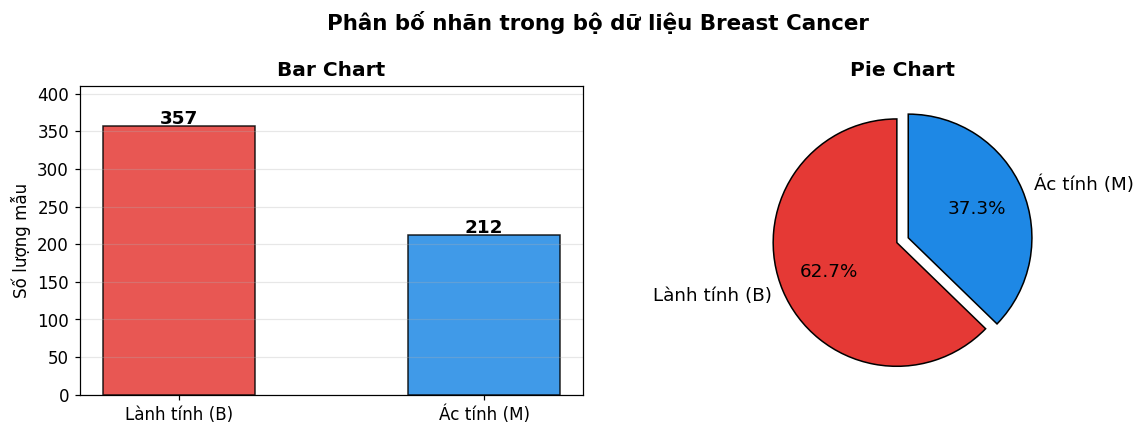


📊 Tổng số mẫu   : 569
   Ác tính (M)   : 212 mẫu (37.3%)
   Lành tính (B) : 357 mẫu (62.7%)


In [7]:
# ── Phân bố nhãn (diagnosis) ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Phân bố nhãn trong bộ dữ liệu Breast Cancer", fontsize=14, fontweight='bold')

counts = df_raw['diagnosis'].value_counts()
labels_map = {'M': 'Ác tính (M)', 'B': 'Lành tính (B)'}
colors = ['#E53935', '#1E88E5']

# Bar chart
bars = axes[0].bar([labels_map[k] for k in counts.index], counts.values,
                   color=colors, edgecolor='black', alpha=0.85, width=0.5)
axes[0].set_title('Bar Chart', fontweight='bold')
axes[0].set_ylabel('Số lượng mẫu')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 3, str(val),
                 ha='center', fontweight='bold', fontsize=12)
axes[0].set_ylim(0, counts.max() * 1.15)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(counts.values,
            labels=[labels_map[k] for k in counts.index],
            colors=colors, autopct='%1.1f%%',
            startangle=90, explode=[0.05, 0.05],
            wedgeprops={'edgecolor': 'black'},
            textprops={'fontsize': 12})
axes[1].set_title('Pie Chart', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n📊 Tổng số mẫu   : {len(df_raw)}")
print(f"   Ác tính (M)   : {counts.get('M', 0)} mẫu ({counts.get('M',0)/len(df_raw)*100:.1f}%)")
print(f"   Lành tính (B) : {counts.get('B', 0)} mẫu ({counts.get('B',0)/len(df_raw)*100:.1f}%)")


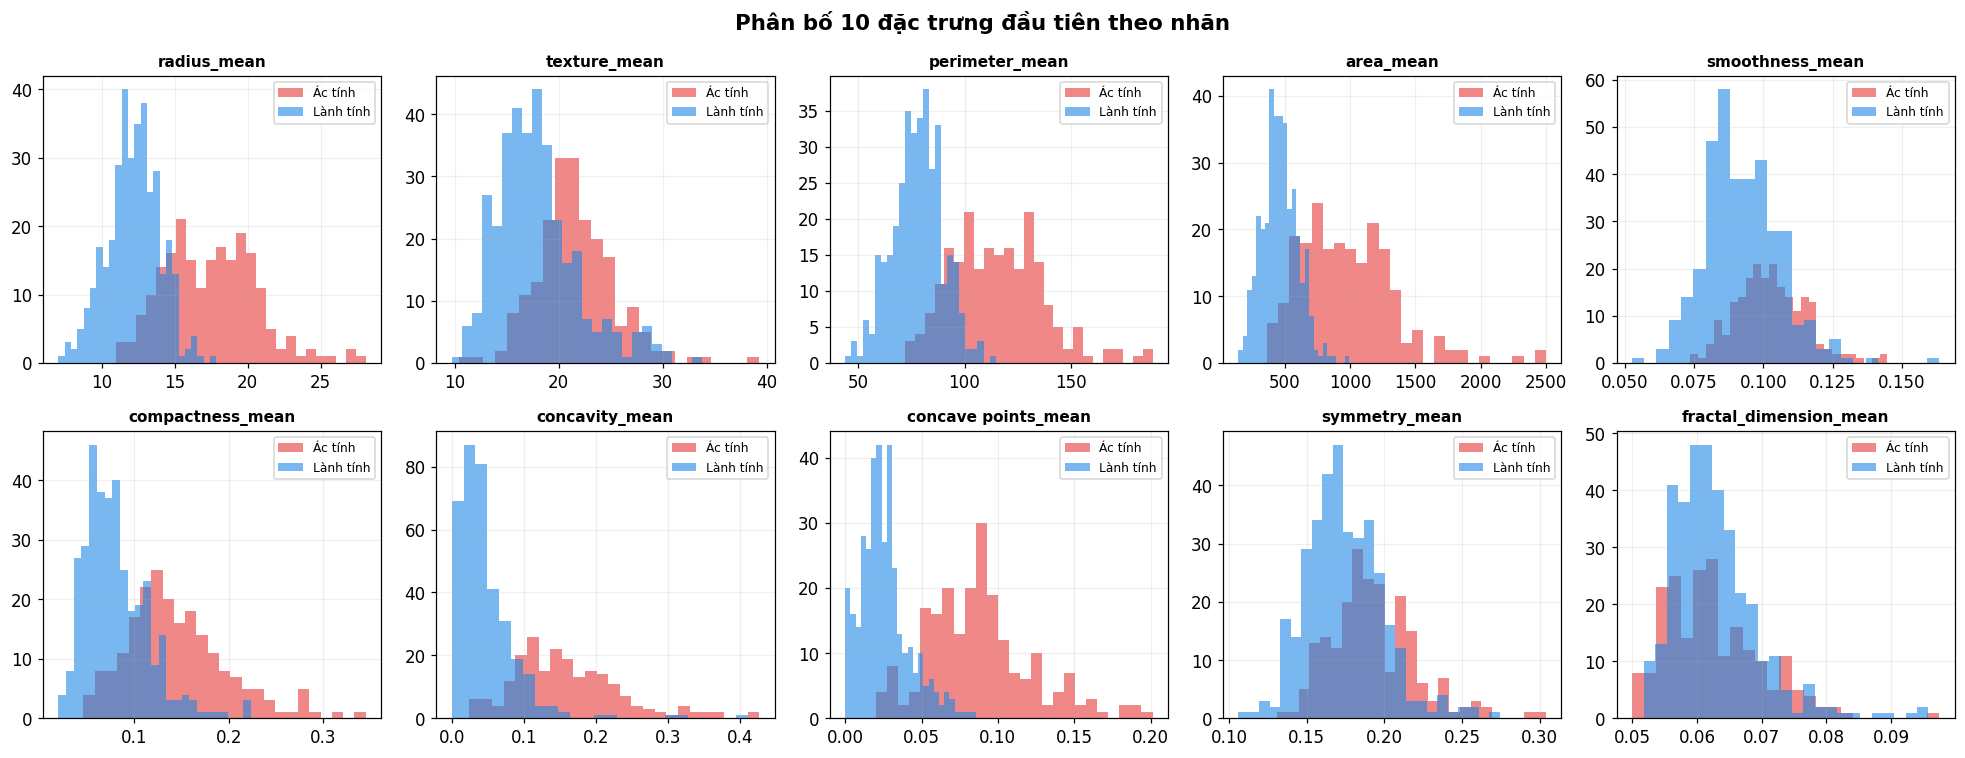

In [8]:
# ── Histogram phân bố 10 đặc trưng đầu tiên ──────────────────────────────────
feature_cols = [c for c in df_raw.columns if c not in ['id', 'diagnosis', 'Unnamed: 32']]
top10 = feature_cols[:10]

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle('Phân bố 10 đặc trưng đầu tiên theo nhãn', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), top10):
    for label, color, name in [('M', '#E53935', 'Ác tính'), ('B', '#1E88E5', 'Lành tính')]:
        ax.hist(df_raw[df_raw['diagnosis'] == label][col],
                bins=25, alpha=0.6, color=color, label=name, edgecolor='none')
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


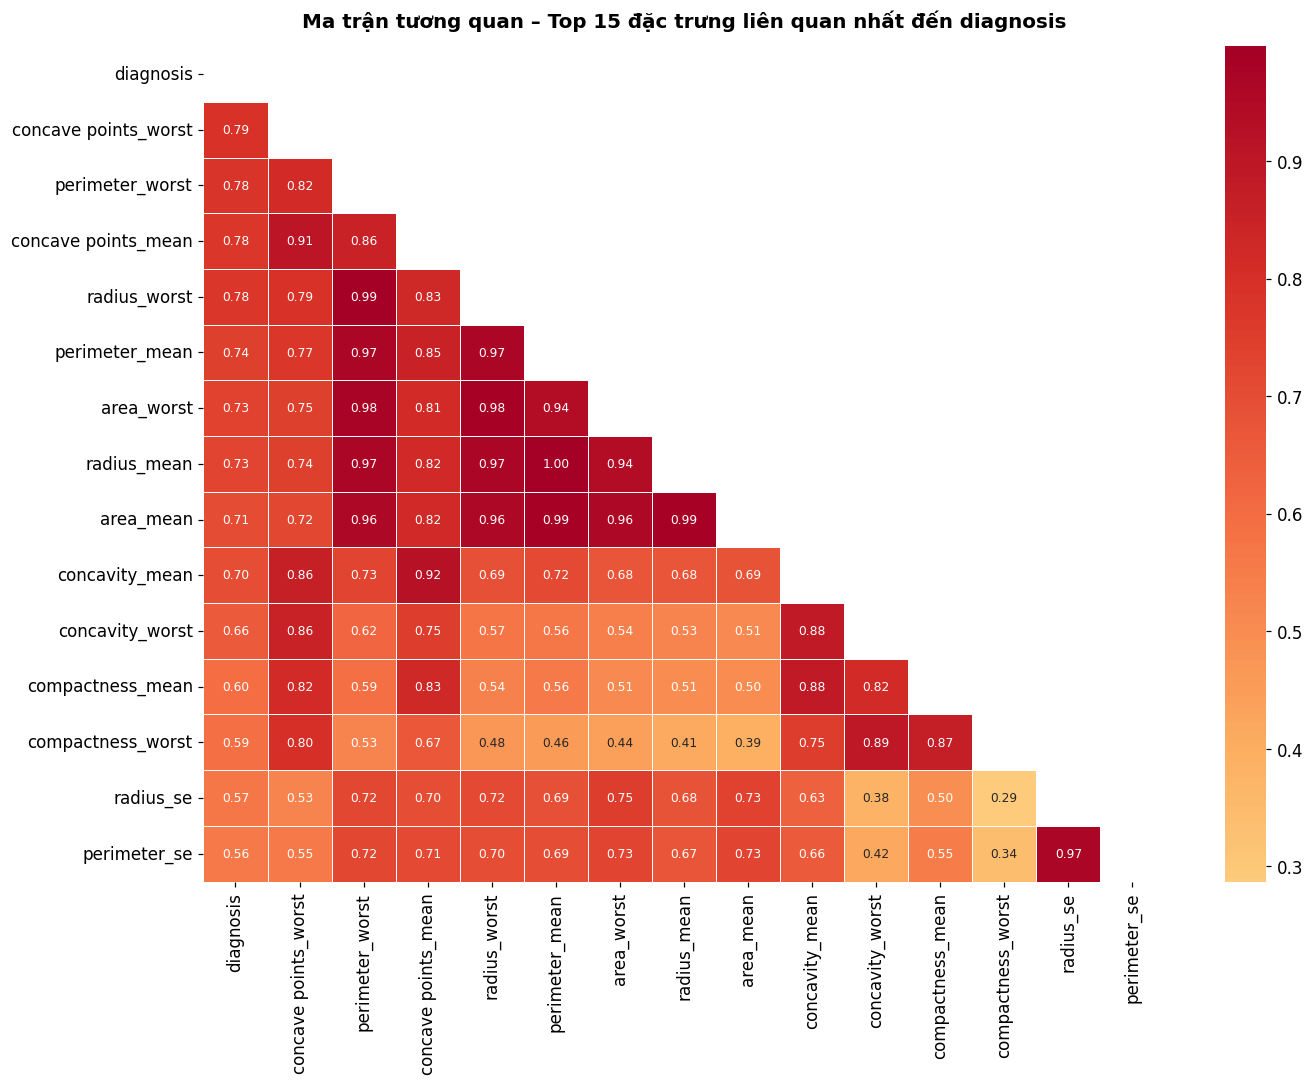

In [9]:
# ── Heatmap tương quan (top 15 đặc trưng) ────────────────────────────────────
df_corr = df_raw.drop(columns=[c for c in ['id', 'Unnamed: 32'] if c in df_raw.columns])
df_corr['diagnosis'] = (df_corr['diagnosis'] == 'M').astype(int)

top15 = df_corr.corr()['diagnosis'].abs().nlargest(15).index.tolist()
corr_matrix = df_corr[top15].corr()

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlBu_r', center=0, linewidths=0.4,
            annot_kws={'size': 8})
plt.title('Ma trận tương quan – Top 15 đặc trưng liên quan nhất đến diagnosis',
          fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


## Chương 3: Tiền xử lý dữ liệu

In [26]:
# ── 3.1 Xóa cột không cần thiết ──────────────────────────────────────────────
df = df_raw.copy()
drop_cols = [c for c in df.columns if 'id' in c.lower() or 'unnamed' in c.lower()]
df.drop(columns=drop_cols, inplace=True)
print(f"✅ Đã xóa cột: {drop_cols}")

# ── 3.2 Xóa dòng có giá trị thiếu ────────────────────────────────────────────
before = len(df)
df.dropna(inplace=True)
print(f"✅ Xóa {before - len(df)} dòng có giá trị thiếu (còn {len(df)} dòng)")

# ── 3.3 Mã hóa nhãn: M → +1 (ác tính), B → -1 (lành tính) ──────────────────
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': -1})
print(f"\n✅ Mã hóa nhãn:  M (Ác tính) → +1  |  B (Lành tính) → -1")
print(f"   Phân bố nhãn sau mã hóa:")
print(df['diagnosis'].value_counts().rename({1: 'Ác tính (+1)', -1: 'Lành tính (-1)'}))

df.head()


✅ Đã xóa cột: ['id', 'Unnamed: 32']
✅ Xóa 0 dòng có giá trị thiếu (còn 569 dòng)

✅ Mã hóa nhãn:  M (Ác tính) → +1  |  B (Lành tính) → -1
   Phân bố nhãn sau mã hóa:
diagnosis
Lành tính (-1)    357
Ác tính (+1)      212
Name: count, dtype: int64


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [27]:
# ── 3.4 Tách X, y ─────────────────────────────────────────────────────────────
X = df.drop('diagnosis', axis=1).values
y = df['diagnosis'].values
feature_names = df.drop('diagnosis', axis=1).columns.tolist()

print(f"✅ X shape: {X.shape}  |  y shape: {y.shape}")
print(f"   Số đặc trưng: {X.shape[1]}")

# ── 3.5 Chia tập Train / Test (80 / 20) ──────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✅ Chia tập dữ liệu (stratified):")
print(f"   Train : {X_train.shape[0]} mẫu  ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"   Test  : {X_test.shape[0]}  mẫu  ({X_test.shape[0]/len(X)*100:.0f}%)")

# ── 3.6 Chuẩn hóa Min-Max Scaling (fit trên train) ───────────────────────────
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(f"\n✅ Chuẩn hóa MinMaxScaler → Giá trị trong [0, 1]")
print(f"   Train min: {X_train.min():.2f}  |  Train max: {X_train.max():.2f}")


✅ X shape: (569, 30)  |  y shape: (569,)
   Số đặc trưng: 30

✅ Chia tập dữ liệu (stratified):
   Train : 455 mẫu  (80%)
   Test  : 114  mẫu  (20%)

✅ Chuẩn hóa MinMaxScaler → Giá trị trong [0, 1]
   Train min: 0.00  |  Train max: 1.00


## Chương 4: Cài đặt AdaBoost từ Scratch

### 4.1 Lớp `DecisionStump` – Mô hình học yếu

Mỗi **Decision Stump** là một cây quyết định chỉ có 1 nút, phân loại dựa trên **1 đặc trưng** và **1 ngưỡng**:

$$
h(x) = \begin{cases} +1 & \text{nếu } x_{j} \geq \text{threshold} \\ -1 & \text{ngược lại} \end{cases}
$$

### 4.2 Thuật toán AdaBoost

**Bước 1:** Khởi tạo trọng số đều: $w_i = \frac{1}{N}$

**Bước 2:** Lặp $t = 1, 2, ..., T$:
- Huấn luyện weak learner $h_t(x)$ với trọng số $\{w_i\}$
- Tính tỷ lệ lỗi: $\varepsilon_t = \sum_i w_i \cdot \mathbf{1}[y_i \neq h_t(x_i)]$
- Tính trọng số mô hình: $\alpha_t = \frac{1}{2} \ln\left(\frac{1 - \varepsilon_t}{\varepsilon_t}\right)$
- Cập nhật trọng số: $w_i \leftarrow w_i \cdot e^{-\alpha_t y_i h_t(x_i)}$
- Chuẩn hóa: $w_i \leftarrow \frac{w_i}{\sum_j w_j}$

**Bước 3:** Dự đoán cuối: $F(x) = \text{sign}\left(\sum_{t=1}^{T} \alpha_t h_t(x)\right)$


### Mục tiêu & ý nghĩa của bài làm

Bài này không chỉ để "chạy ra kết quả", mà để **chứng minh hiểu AdaBoost** bằng cách tự cài đặt từ scratch và áp dụng vào bài toán y tế thực tế.

- **Mục tiêu chính:** Phân loại u lành/ác tính từ dữ liệu Breast Cancer Wisconsin.
- **Vì sao AdaBoost:** Kết hợp nhiều mô hình yếu (decision stump) để tạo mô hình mạnh, giảm lỗi tổng thể.
- **Ý nghĩa học thuật:** Hiểu rõ cơ chế cập nhật trọng số mẫu, trọng số mô hình $\alpha$, và cách ensemble cải thiện hiệu suất.
- **Ý nghĩa thực tiễn:** Bài toán phân loại y tế cần độ chính xác cao; AdaBoost là baseline mạnh để so sánh với các mô hình khác.


In [28]:
# ══════════════════════════════════════════════════════════════════
# LỚP DECISIONSTUMP – Mô hình học yếu
# ══════════════════════════════════════════════════════════════════

class DecisionStump:
    """
    Cây quyết định cụt (1 nút) – weak learner trong AdaBoost.

    Thuộc tính:
        polarity    : Chiều so sánh (+1 hoặc -1)
        feature_idx : Chỉ số đặc trưng được chọn
        threshold   : Ngưỡng phân chia
        alpha       : Trọng số (amount of say) trong tổng thể
    """
    def __init__(self):
        self.polarity    = 1
        self.feature_idx = None
        self.threshold   = None
        self.alpha       = None

    def predict(self, X):
        """Dự đoán nhãn -1 hoặc +1 cho từng mẫu."""
        n_samples = X.shape[0]
        X_col     = X[:, self.feature_idx]
        preds     = np.ones(n_samples)

        if self.polarity == 1:
            preds[X_col < self.threshold] = -1
        else:
            preds[X_col > self.threshold] = -1

        return preds


print("✅ Đã định nghĩa lớp DecisionStump")


✅ Đã định nghĩa lớp DecisionStump


In [29]:
# ══════════════════════════════════════════════════════════════════
# LỚP ADABOOST – Tự cài đặt từ scratch
# ══════════════════════════════════════════════════════════════════

class AdaBoost:
    """
    AdaBoost (Adaptive Boosting) – tự cài đặt từ scratch.

    Tham số:
        n_clf : Số vòng boosting (số weak learner)
    """

    def __init__(self, n_clf=50):
        self.n_clf = n_clf
        self.clfs  = []   # Danh sách DecisionStump đã huấn luyện

    # ── fit ───────────────────────────────────────────────────────
    def fit(self, X, y):
        """Huấn luyện AdaBoost."""
        n_samples, n_features = X.shape
        self.clfs = []

        # Bước 1: Khởi tạo trọng số đều nhau
        w = np.full(n_samples, 1 / n_samples)

        for _ in range(self.n_clf):
            clf       = DecisionStump()
            min_error = float('inf')

            # Bước 2a: Tìm stump tốt nhất (brute-force qua mọi feature & threshold)
            for feat_i in range(n_features):
                X_col      = X[:, feat_i]
                thresholds = np.unique(X_col)

                for thr in thresholds:
                    for polarity in [1, -1]:
                        preds = np.ones(n_samples)
                        if polarity == 1:
                            preds[X_col < thr] = -1
                        else:
                            preds[X_col > thr] = -1

                        # Bước 2b: Tỷ lệ lỗi có trọng số
                        error = np.sum(w[y != preds])

                        # Nếu lỗi > 0.5 → đảo chiều (vẫn có thông tin)
                        if error > 0.5:
                            error   = 1 - error
                            polarity = -polarity

                        if error < min_error:
                            min_error        = error
                            clf.polarity     = polarity
                            clf.feature_idx  = feat_i
                            clf.threshold    = thr

            # Bước 2c: Tính alpha (amount of say)
            EPS       = 1e-10
            clf.alpha = 0.5 * np.log((1 - min_error) / (min_error + EPS))

            # Bước 2d & 2e: Cập nhật và chuẩn hóa trọng số mẫu
            preds = clf.predict(X)
            w    *= np.exp(-clf.alpha * y * preds)
            w    /= np.sum(w)

            self.clfs.append(clf)

    # ── predict ───────────────────────────────────────────────────
    def predict(self, X):
        """Dự đoán nhãn: F(x) = sign(Σ α_t · h_t(x))"""
        agg = np.sum([clf.alpha * clf.predict(X) for clf in self.clfs], axis=0)
        return np.where(agg >= 0, 1, -1)

    # ── predict_score (dùng cho ROC curve) ────────────────────────
    def predict_score(self, X):
        """Trả về tổng có trọng số (chưa sign) để vẽ ROC curve."""
        return np.sum([clf.alpha * clf.predict(X) for clf in self.clfs], axis=0)


print("✅ Đã định nghĩa lớp AdaBoost")


✅ Đã định nghĩa lớp AdaBoost


## Chương 5: Huấn luyện & Đánh giá mô hình

In [30]:
# ── Hàm đánh giá ─────────────────────────────────────────────────────────────
def acc(y_true, y_pred):
    return np.sum(y_true == y_pred) / len(y_true)


# ── Huấn luyện ───────────────────────────────────────────────────────────────
N_CLF = 50   # ← Bạn có thể thay đổi số này

print(f"⏳ Đang huấn luyện AdaBoost với {N_CLF} weak classifiers...")
model = AdaBoost(n_clf=N_CLF)
model.fit(X_train, y_train)
print(f"✅ Huấn luyện xong!")


⏳ Đang huấn luyện AdaBoost với 50 weak classifiers...
✅ Huấn luyện xong!


In [31]:
# ── Dự đoán & tính chỉ số ────────────────────────────────────────────────────
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

acc_train = acc(y_train, y_pred_train) * 100
acc_test  = acc(y_test,  y_pred_test)  * 100
prec      = precision_score(y_test, y_pred_test)
rec       = recall_score(y_test, y_pred_test)
f1        = f1_score(y_test, y_pred_test)

print("=" * 50)
print("  KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ADABOOST")
print("=" * 50)
print(f"  Số weak classifiers  : {N_CLF}")
print(f"  Accuracy (Train)     : {acc_train:.2f}%")
print(f"  Accuracy (Test)      : {acc_test:.2f}%")
print(f"  Precision            : {prec:.4f}")
print(f"  Recall               : {rec:.4f}")
print(f"  F1-Score             : {f1:.4f}")
print("=" * 50)
print()
print("Classification Report (Tập Test):")
print(classification_report(y_test, y_pred_test,
                            target_names=['Lành tính (B)', 'Ác tính (M)']))


  KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ADABOOST
  Số weak classifiers  : 50
  Accuracy (Train)     : 100.00%
  Accuracy (Test)      : 98.25%
  Precision            : 1.0000
  Recall               : 0.9524
  F1-Score             : 0.9756

Classification Report (Tập Test):
               precision    recall  f1-score   support

Lành tính (B)       0.97      1.00      0.99        72
  Ác tính (M)       1.00      0.95      0.98        42

     accuracy                           0.98       114
    macro avg       0.99      0.98      0.98       114
 weighted avg       0.98      0.98      0.98       114



## Chương 6: Trực quan hóa kết quả

### 6.1 Confusion Matrix

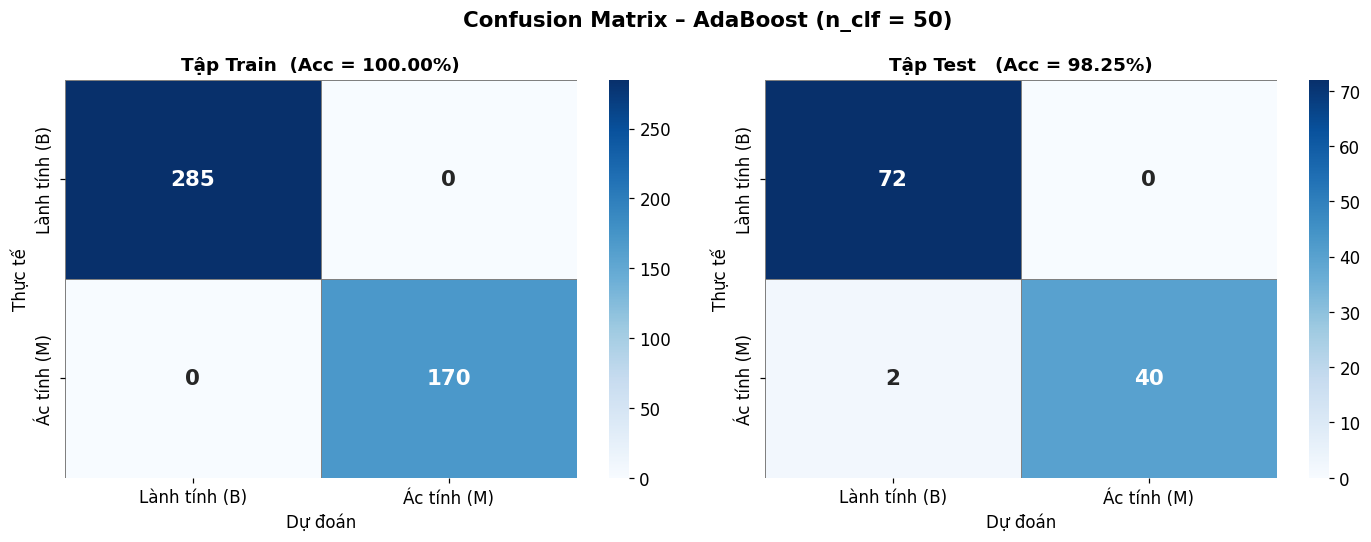

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Confusion Matrix – AdaBoost (n_clf = {N_CLF})',
             fontsize=14, fontweight='bold')

for ax, y_true, y_pred, title in [
    (axes[0], y_train, y_pred_train, f'Tập Train  (Acc = {acc_train:.2f}%)'),
    (axes[1], y_test,  y_pred_test,  f'Tập Test   (Acc = {acc_test:.2f}%)'),
]:
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Lành tính (B)', 'Ác tính (M)'],
                yticklabels=['Lành tính (B)', 'Ác tính (M)'],
                linewidths=0.5, linecolor='gray',
                annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Dự đoán', fontsize=11)
    ax.set_ylabel('Thực tế', fontsize=11)

plt.tight_layout()
plt.show()


### 6.2 Phân bố trọng số Alpha của các Weak Classifier

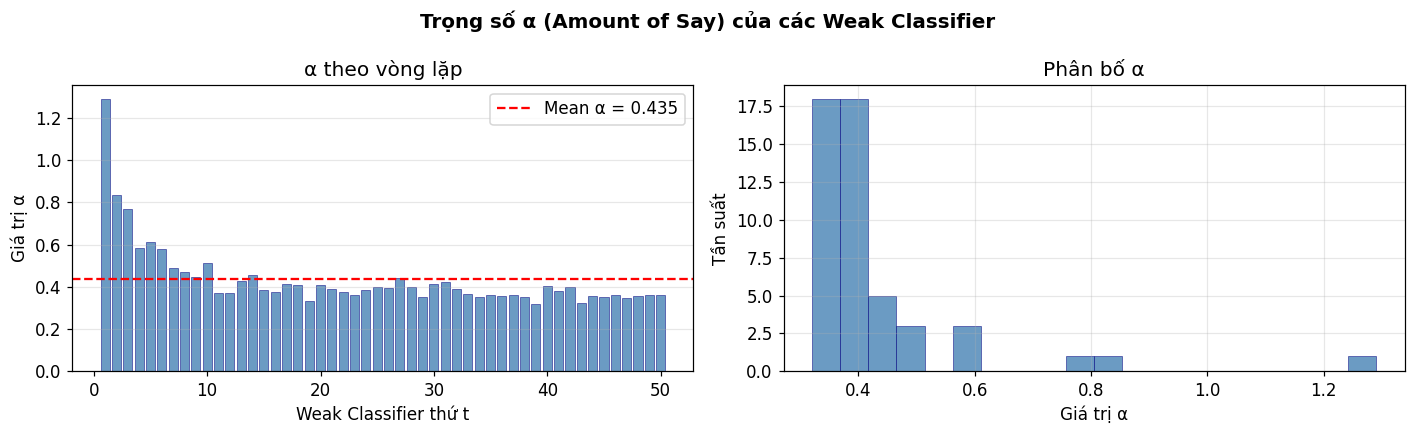

α min  = 0.3201
α max  = 1.2908
α mean = 0.4347


In [33]:
alphas = [clf.alpha for clf in model.clfs]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Trọng số α (Amount of Say) của các Weak Classifier',
             fontsize=13, fontweight='bold')

# Bar chart
axes[0].bar(range(1, len(alphas) + 1), alphas,
            color='steelblue', alpha=0.8, edgecolor='navy', linewidth=0.4)
axes[0].set_xlabel('Weak Classifier thứ t')
axes[0].set_ylabel('Giá trị α')
axes[0].set_title('α theo vòng lặp')
axes[0].grid(axis='y', alpha=0.3)
axes[0].axhline(np.mean(alphas), color='red', linestyle='--',
                label=f'Mean α = {np.mean(alphas):.3f}')
axes[0].legend()

# Histogram phân bố alpha
axes[1].hist(alphas, bins=20, color='steelblue', edgecolor='navy',
             alpha=0.8, linewidth=0.4)
axes[1].set_xlabel('Giá trị α')
axes[1].set_ylabel('Tần suất')
axes[1].set_title('Phân bố α')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"α min  = {min(alphas):.4f}")
print(f"α max  = {max(alphas):.4f}")
print(f"α mean = {np.mean(alphas):.4f}")


### 6.3 Trực quan hóa PCA 2D

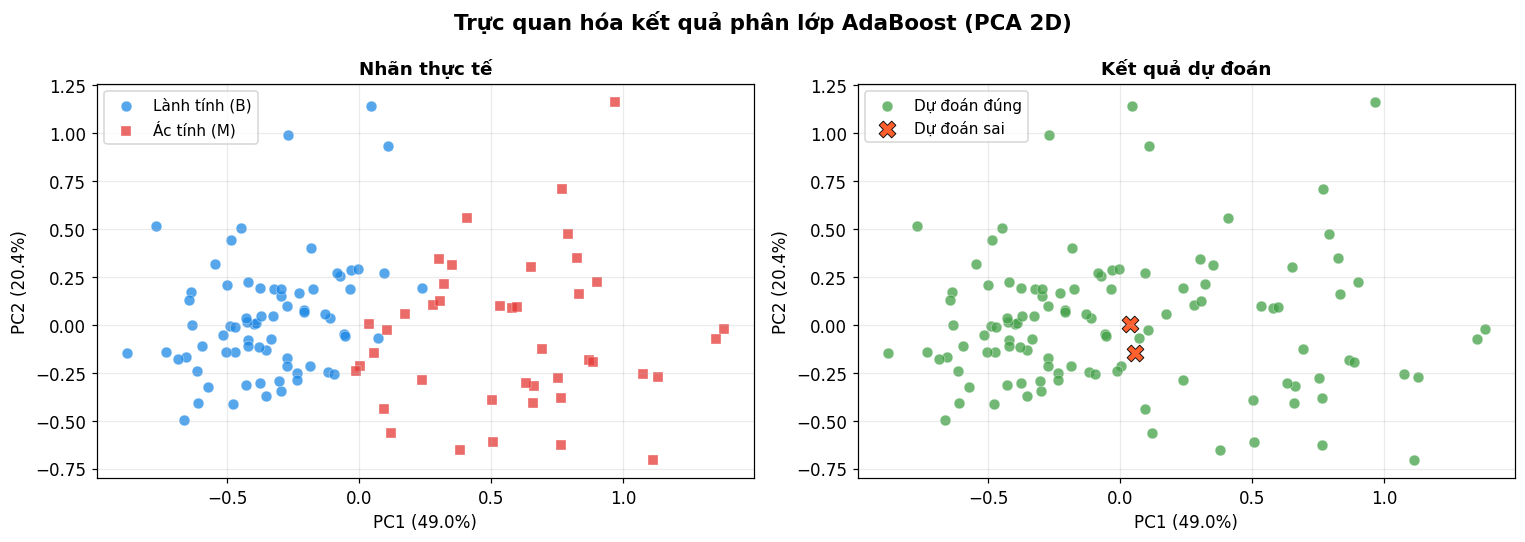


PCA giải thích 69.5% phương sai
Số mẫu dự đoán sai: 2 / 114


In [34]:
pca      = PCA(n_components=2)
X_test2D = pca.fit_transform(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Trực quan hóa kết quả phân lớp AdaBoost (PCA 2D)',
             fontsize=14, fontweight='bold')

# ── Nhãn thực tế ──────────────────────────────────────────────────────────────
for label, color, marker, name in [
    (-1, '#1E88E5', 'o', 'Lành tính (B)'),
    ( 1, '#E53935', 's', 'Ác tính (M)'),
]:
    idx = y_test == label
    axes[0].scatter(X_test2D[idx, 0], X_test2D[idx, 1],
                    c=color, marker=marker, label=name,
                    alpha=0.75, edgecolors='white', linewidths=0.3, s=50)
axes[0].set_title('Nhãn thực tế', fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.25)

# ── Kết quả dự đoán ───────────────────────────────────────────────────────────
correct   = y_test == y_pred_test
incorrect = ~correct
axes[1].scatter(X_test2D[correct, 0],   X_test2D[correct, 1],
                c='#43A047', marker='o', label='Dự đoán đúng',
                alpha=0.75, edgecolors='white', linewidths=0.3, s=50)
axes[1].scatter(X_test2D[incorrect, 0], X_test2D[incorrect, 1],
                c='#FF5722', marker='X', label='Dự đoán sai',
                alpha=0.95, edgecolors='black', linewidths=0.6, s=120)
axes[1].set_title('Kết quả dự đoán', fontsize=12, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f"\nPCA giải thích {sum(pca.explained_variance_ratio_)*100:.1f}% phương sai")
print(f"Số mẫu dự đoán sai: {incorrect.sum()} / {len(y_test)}")


### 6.4 ROC Curve

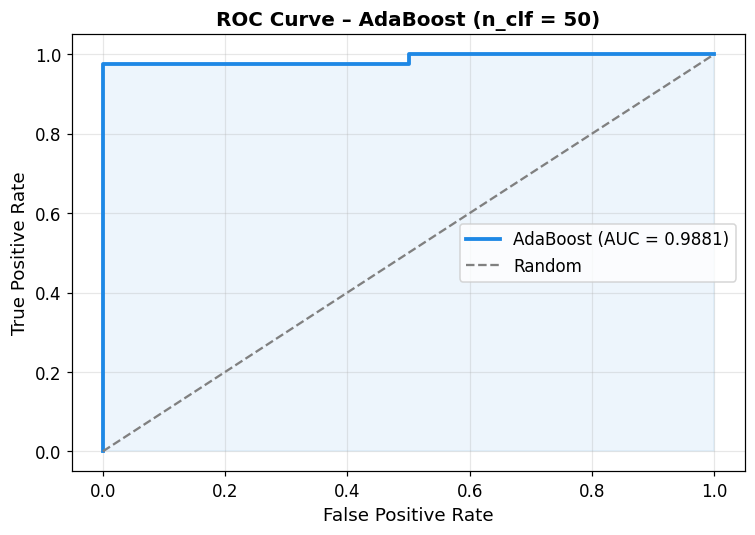

AUC = 0.9881


In [35]:
scores = model.predict_score(X_test)
fpr, tpr, _ = roc_curve(y_test, scores)
roc_auc      = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#1E88E5', lw=2.5,
         label=f'AdaBoost (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Random')
plt.fill_between(fpr, tpr, alpha=0.08, color='#1E88E5')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'ROC Curve – AdaBoost (n_clf = {N_CLF})', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC = {roc_auc:.4f}")


## Chương 7: Thực nghiệm – Accuracy theo số Weak Classifier

So sánh độ chính xác khi thay đổi số lượng weak classifier từ 1 đến 100.  
*(Cell này có thể mất 1–2 phút do phải huấn luyện nhiều mô hình)*


In [36]:
clf_range   = list(range(1, 101, 5))
train_accs  = []
test_accs   = []

print("⏳ Đang thực nghiệm... (vui lòng chờ)")
for n in clf_range:
    m = AdaBoost(n_clf=n)
    m.fit(X_train, y_train)
    train_accs.append(acc(y_train, m.predict(X_train)) * 100)
    test_accs.append(acc(y_test,   m.predict(X_test))  * 100)

print(f"✅ Xong! Kết quả tốt nhất trên Test: {max(test_accs):.2f}% (n_clf = {clf_range[np.argmax(test_accs)]})")


⏳ Đang thực nghiệm... (vui lòng chờ)
✅ Xong! Kết quả tốt nhất trên Test: 98.25% (n_clf = 46)


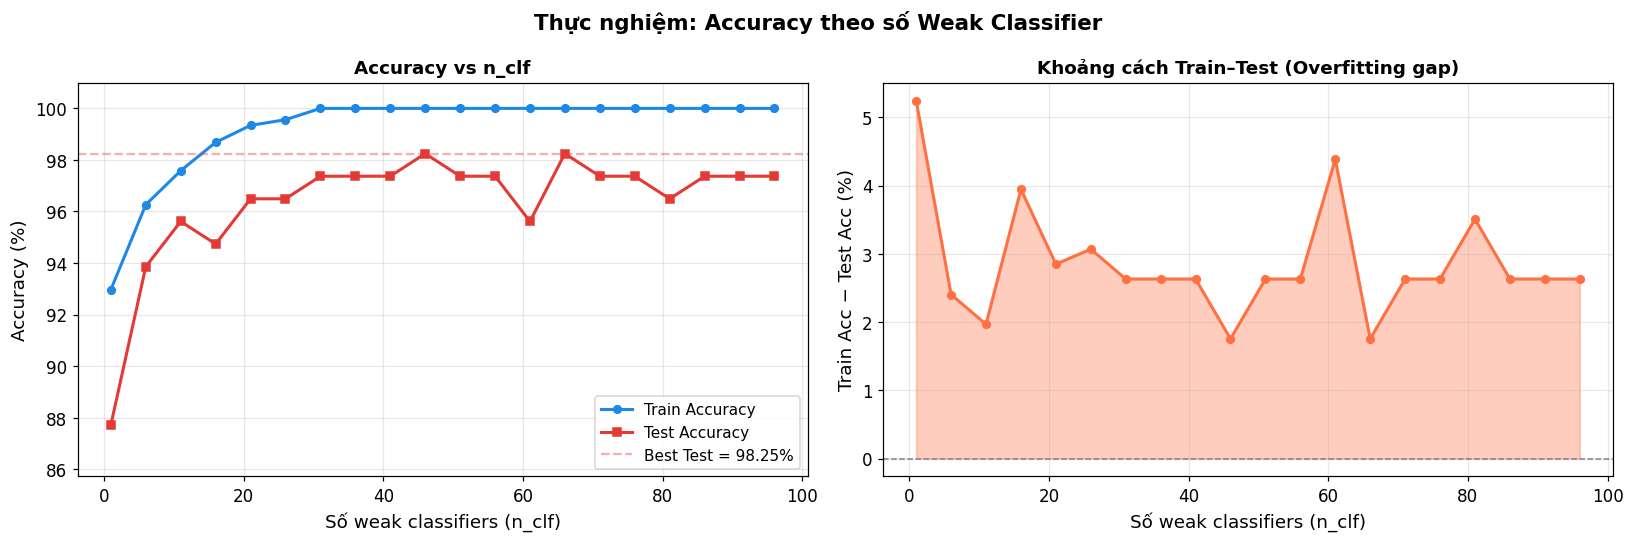

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Thực nghiệm: Accuracy theo số Weak Classifier', fontsize=14, fontweight='bold')

# ── Line chart ────────────────────────────────────────────────────────────────
axes[0].plot(clf_range, train_accs, 'o-', color='#1E88E5',
             label='Train Accuracy', markersize=5, linewidth=2)
axes[0].plot(clf_range, test_accs, 's-', color='#E53935',
             label='Test Accuracy',  markersize=5, linewidth=2)
axes[0].axhline(max(test_accs), color='#E53935', linestyle='--', alpha=0.4,
                label=f'Best Test = {max(test_accs):.2f}%')
axes[0].set_xlabel('Số weak classifiers (n_clf)', fontsize=12)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title('Accuracy vs n_clf', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].set_ylim([min(min(train_accs), min(test_accs)) - 2, 101])

# ── Gap chart (Overfitting) ───────────────────────────────────────────────────
gap = [tr - te for tr, te in zip(train_accs, test_accs)]
axes[1].fill_between(clf_range, gap, alpha=0.35, color='#FF7043')
axes[1].plot(clf_range, gap, 'o-', color='#FF7043', markersize=5, linewidth=2)
axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[1].set_xlabel('Số weak classifiers (n_clf)', fontsize=12)
axes[1].set_ylabel('Train Acc − Test Acc (%)', fontsize=12)
axes[1].set_title('Khoảng cách Train–Test (Overfitting gap)', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [38]:
# ── Bảng tổng kết ─────────────────────────────────────────────────────────────
%pip install jinja2
results_df = pd.DataFrame({
    'n_clf'         : clf_range,
    'Train Acc (%)' : [round(a, 2) for a in train_accs],
    'Test Acc (%)'  : [round(a, 2) for a in test_accs],
    'Gap (%)'       : [round(tr - te, 2) for tr, te in zip(train_accs, test_accs)]
})

print("Bảng kết quả thực nghiệm:")
results_df.style.background_gradient(subset=['Test Acc (%)'], cmap='Greens') \
                .background_gradient(subset=['Gap (%)'],      cmap='Reds_r')


Note: you may need to restart the kernel to use updated packages.
Bảng kết quả thực nghiệm:



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


,n_clf,Train Acc (%),Test Acc (%),Gap (%)
0,1,92.970000,87.720000,5.250000
1,6,96.260000,93.860000,2.400000
2,11,97.580000,95.610000,1.970000
3,16,98.680000,94.740000,3.940000
4,21,99.340000,96.490000,2.850000
5,26,99.560000,96.490000,3.070000
6,31,100.000000,97.370000,2.630000
7,36,100.000000,97.370000,2.630000
8,41,100.000000,97.370000,2.630000
9,46,100.000000,98.250000,1.750000


## Kết luận

| Chỉ số | Giá trị |
|--------|---------|
| Bộ dữ liệu | Breast Cancer Wisconsin |
| Số mẫu | 569 |
| Số đặc trưng | 30 |
| Thuật toán | AdaBoost (scratch) |
| Weak Learner | Decision Stump |
| Train/Test split | 80% / 20% |

### Ưu điểm của AdaBoost
- Tự động tập trung vào các mẫu khó phân loại (tăng trọng số)
- Kết hợp nhiều mô hình yếu thành mô hình mạnh
- Ít tham số cần tinh chỉnh (chủ yếu là `n_clf`)
- Hiệu suất cao trên bộ dữ liệu y tế có ít nhiễu

### Hạn chế
- Nhạy cảm với **outlier** và **nhiễu** (do tăng trọng số mạnh)
- Tốc độ huấn luyện chậm hơn so với Random Forest khi `n_clf` lớn
- Dễ bị **overfitting** nếu dữ liệu có nhiều nhiễu
